In [1]:
%%capture

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
dyn.get_all_dependencies_version()
dyn.pl.style()

%load_ext autoreload
%autoreload 2

In [2]:
adata_hsc_raw = dyn.sample_data.hematopoiesis_raw()
adata_hsc_raw

AnnData object with n_obs × n_vars = 1947 × 26193
    obs: 'batch', 'cell_type', 'time'
    var: 'gene_name_mapping'
    uns: 'genes_to_use'
    obsm: 'X_umap'
    layers: 'new', 'spliced', 'total', 'unspliced'

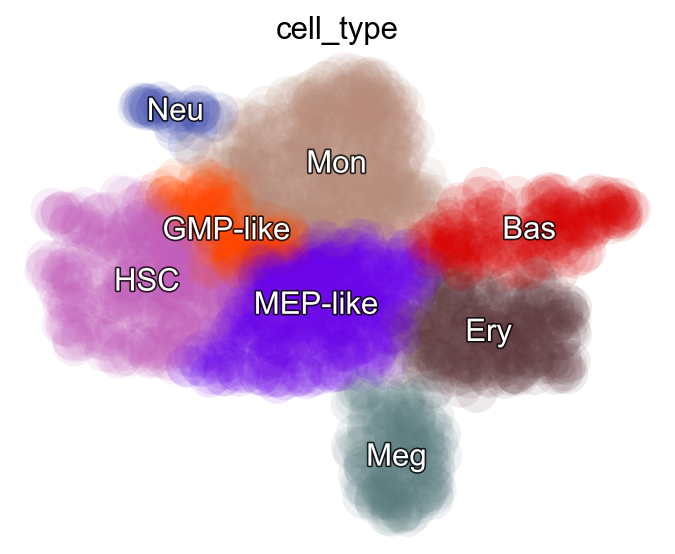

In [3]:
dyn.pl.umap(
    adata_hsc_raw,
    color='cell_type', 
    #s_kwargs_dict={'adjust_legend':True},
)

In [4]:
selected_genes_to_use = adata_hsc_raw.uns["genes_to_use"]

In [5]:
preprocessor = dyn.pp.Preprocessor(force_gene_list=selected_genes_to_use)
preprocessor.config_monocle_recipe(adata_hsc_raw, n_top_genes=len(selected_genes_to_use))                               
preprocessor.preprocess_adata_monocle(
    adata_hsc_raw,
    tkey="time",
    experiment_type="one-shot",
)

|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
16 input query terms found dup hits:	[('ENSG00000226519', 2), ('ENSG00000227110', 2), ('ENSG00000228566', 2), ('ENSG00000234162', 2), ('E
458 input query terms found no hit:	['ENSG00000112096', 'ENSG00000132832', 'ENSG00000168078', 'ENSG00000176659', 'ENSG00000189144', 'ENS


|-----> [Preprocessor-monocle] completed [8.1988s]


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/preprocessing/utils.py:734: RuntimeWarning: invalid value encountered in divide
  var_ntr = adata.layers["new"].sum(0) / adata.layers["total"].sum(0)


In [6]:
dyn.tl.reduceDimension(adata_hsc_raw)

|-----> retrieve data for non-linear dimension reduction...
|-----? adata already have basis umap. dimension reduction umap will be skipped! 
set enforce=True to re-performing dimension reduction.
|-----> Start computing neighbor graph...
|-----------> X_data is None, fetching or recomputing...
|-----> fetching X data from layer:None, basis:pca
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [UMAP] completed [0.0920s]


In [7]:
dyn.tl.moments(adata_hsc_raw, group="time")

|-----> calculating first/second moments...
|-----> [moments calculation] completed [14.9903s]


In [8]:
adata_hsc_raw.uns["pp"]["has_splicing"] = False
dyn.tl.dynamics(adata_hsc_raw, group="time", 
                one_shot_method="sci_fate", 
                model="deterministic");

|-----> calculating first/second moments...
|-----> [moments calculation] completed [2.8471s]


estimating alpha: 100%|██████████| 1742/1742 [00:00<00:00, 119650.82it/s]
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/scipy/sparse/_base.py:659: RuntimeWarning: divide by zero encountered in divide
  recip = np.true_divide(1., other)


|-----> calculating first/second moments...


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/tools/utils.py:1606: RuntimeWarning: divide by zero encountered in divide
  params_df.loc[valid_ind, kin_param_pre + "half_life"] = None if gamma is None else np.log(2) / gamma


|-----> [moments calculation] completed [1.9371s]


estimating alpha: 100%|██████████| 1742/1742 [00:00<00:00, 120449.68it/s]
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/scipy/sparse/_base.py:659: RuntimeWarning: divide by zero encountered in divide
  recip = np.true_divide(1., other)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/tools/utils.py:1606: RuntimeWarning: divide by zero encountered in divide
  params_df.loc[valid_ind, kin_param_pre + "half_life"] = None if gamma is None else np.log(2) / gamma


In [9]:
import numpy as np
import dynamo as dyn

def alpha_minus_gamma_s(new, gamma, t, M_s):
    """
    Calculate alpha - gamma * s for a given time point.
    
    Parameters:
    -----------
    new : array-like
        New RNA expression matrix
    gamma : array-like  
        Splicing rate parameters
    t : array-like
        Time points
    M_s : array-like
        Spliced RNA matrix
        
    Returns:
    --------
    alpha_minus_gamma_s : array-like
        Calculated velocity values
    """
    # Convert all inputs to numpy arrays to avoid pandas indexing issues
    if hasattr(new, 'A'):  # sparse matrix
        new_array = new.A.T
    else:
        new_array = np.array(new).T
    
    gamma_array = np.array(gamma)
    t_array = np.array(t)
    
    if hasattr(M_s, 'A'):  # sparse matrix
        M_s_array = M_s.A.T
    else:
        M_s_array = np.array(M_s).T
    
    # equation: alpha = new / (1 - e^{-rt}) * r
    alpha = new_array / (1 - np.exp(-gamma_array[:, None] * t_array[None, :])) * gamma_array[:, None]
    
    gamma_s = gamma_array[:, None] * M_s_array
    alpha_minus_gamma_s = alpha - gamma_s
    return alpha_minus_gamma_s

def calculate_velocity_alpha_minus_gamma_s(adata, gene_subset_key='use_for_pca', 
                                         velocity_layer_name='velocity_alpha_minus_gamma_s'):
    """
    Calculate total RNA velocity using alpha - gamma * s formula for all time points.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object containing expression data and time information
    gene_subset_key : str, default 'use_for_pca'
        Key in adata.var to identify genes to use for calculation
    velocity_layer_name : str, default 'velocity_alpha_minus_gamma_s'
        Name for the output velocity layer
        
    Returns:
    --------
    None (modifies adata in place)
    """
    
    # Get genes to use for calculation
    if gene_subset_key in adata.var.columns:
        pca_genes = adata.var[gene_subset_key]
    else:
        raise ValueError(f"Gene subset key '{gene_subset_key}' not found in adata.var")
    
    # Get basic data
    new_expr = adata[:, pca_genes].layers["M_n"]
    t = adata.obs.time.astype(float)
    M_s = adata.layers["M_s"][:, pca_genes]
    
    # Get unique time points
    unique_times = np.unique(t)
    print(f"Found {len(unique_times)} unique time points: {unique_times}")
    
    # Initialize velocity matrix
    if "velocity_N" in adata.layers:
        velocity_n = adata.layers["velocity_N"].copy()
    else:
        velocity_n = np.zeros_like(adata.X)
    
    valid_velocity_n = velocity_n[:, pca_genes].copy()
    
    # Calculate velocity for each time point
    for time_point in unique_times:
        print(f"Processing time point: {time_point}")
        
        # Get cells for this time point
        time_cells = adata.obs.time == time_point
        n_cells = np.sum(time_cells)
        print(f"  Number of cells: {n_cells}")
        
        # Get gamma parameters for this time point
        gamma_key = f"time_{int(time_point)}_"
        try:
            gamma = dyn.tl.get_vel_params(adata, params="gamma", genes=pca_genes, 
                                        kin_param_pre=gamma_key).astype(float)
        except Exception as e:
            print(f"  Warning: Could not get gamma parameters for time {time_point}: {e}")
            continue
            
        # Calculate velocity for this time point
        velocity_time = alpha_minus_gamma_s(
            new_expr[time_cells, :], 
            gamma, 
            t[time_cells], 
            M_s[time_cells, :]
        )
        
        # Store results
        valid_velocity_n[time_cells, :] = velocity_time.T
        print(f"  Velocity calculation completed for time point {time_point}")
    
    # Update the velocity matrix
    velocity_n[:, pca_genes] = valid_velocity_n.copy()
    adata.layers[velocity_layer_name] = velocity_n.copy()
    
    print(f"Total RNA velocity stored in adata.layers['{velocity_layer_name}']")
# Usage
dyn.tl.calculate_velocity_alpha_minus_gamma_s(adata_hsc_raw)

Found 2 unique time points: [3. 5.]
Processing time point: 3.0
  Number of cells: 1129


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/tools/cell_velocities.py:1062: RuntimeWarning: invalid value encountered in divide
  alpha = new_array / (1 - np.exp(-gamma_array[:, None] * t_array[None, :])) * gamma_array[:, None]


  Velocity calculation completed for time point 3.0
Processing time point: 5.0
  Number of cells: 818
  Velocity calculation completed for time point 5.0
Total RNA velocity stored in adata.layers['velocity_alpha_minus_gamma_s']


In [10]:
dyn.tl.cell_velocities(
    adata_hsc_raw,
    enforce=True,
    X=adata_hsc_raw.layers["M_t"],
    V=adata_hsc_raw.layers["velocity_alpha_minus_gamma_s"],
    method="cosine",
)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 1947 × 21805
    obs: 'batch', 'cell_type', 'time', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'new_Size_Factor', 'initial_new_cell_size', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'ntr'
    var: 'gene_name_mapping', 'query', 'scopes', '_id', '_score', 'symbol', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'score', 'log_m', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'genes_to_use', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'neighbors', 'time_3_vel_params_names', 'time_5_vel_params_names', 'dynamics', 'grid_velocity_umap'
    obsm: 'X_umap', 'X_pca', 'velocity_umap'
    varm: 'time_3_vel_params', 'time_5_vel_params'
    layers: 'new', 'spliced', 'total', 'unspliced', 'X_spliced', 'X_new', 'X_total', 'X_unspliced', 'M_u', 'M_u

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


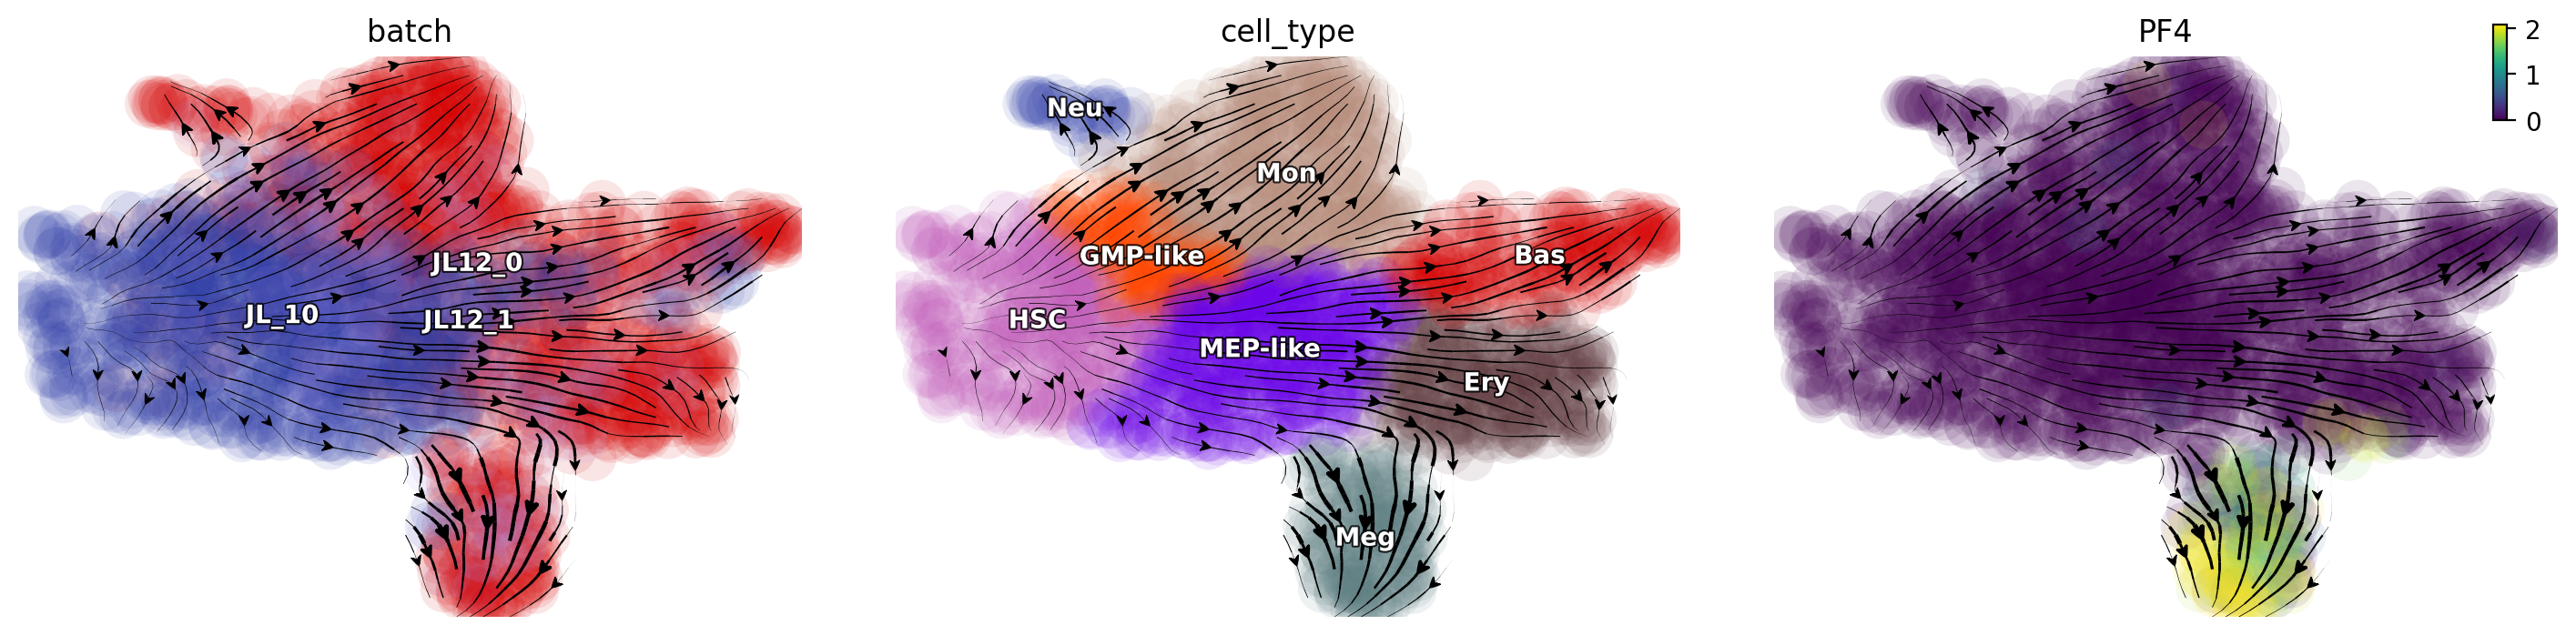

In [11]:
dyn.pl.streamline_plot(
    adata_hsc_raw,
    color=["batch", "cell_type", "PF4"],
    ncols=4,
    basis="umap",
)

In [65]:
dyn.vf.VectorField(adata_hsc_raw, M=1000, basis='umap',pot_curl_div=True)

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [4.4504s]
|-----> [VectorField] completed [4.5202s]


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


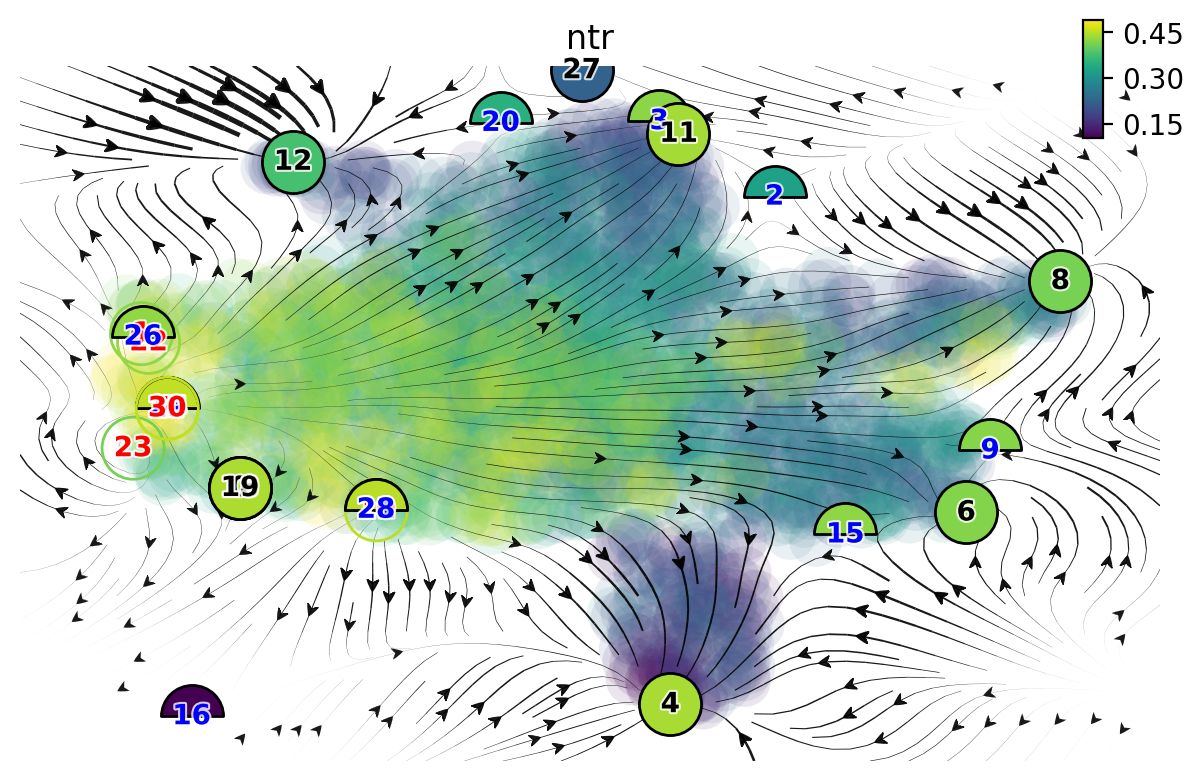

In [83]:
dyn.vf.topography(adata_hsc_raw, n=100, basis='umap')
dyn.pl.topography(
    adata_hsc_raw,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    streamline_alpha=0.9,
)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


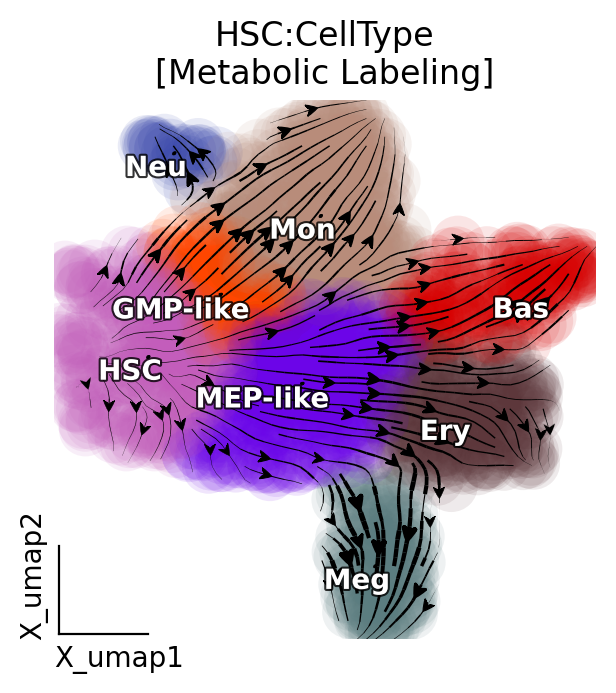

In [74]:
%matplotlib inline
import matplotlib.pyplot as plt
#ov.plot_set()
adata=adata_hsc_raw
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.streamline_plot(adata, color=['cell_type'], 
                       basis='umap',
                       #color_key=color_dict,
                       title='HSC:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=1,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:CellType\n[Metabolic Labeling]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

#ax.xaxis.set_label_coords(0.07, 0.07)
#ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Label_HSC_Velo.png', dpi=300, bbox_inches='tight')
fig.savefig(f'figures/fig3/Label_HSC_Velo.svg', dpi=300, bbox_inches='tight')

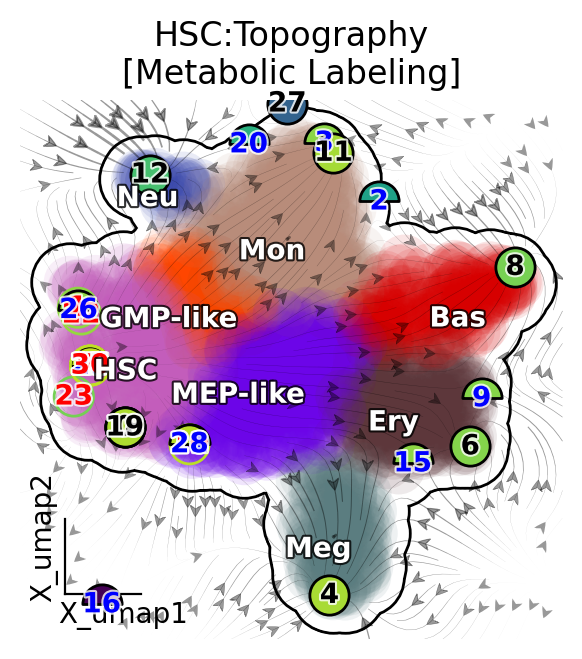

In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata, basis='umap',
                  fps_basis='umap',background='white', 
                  color=[ 'cell_type'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('HSC:Topography\n[Metabolic Labeling]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()


ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)

fig.savefig(f'figures/fig3/Label_HSC_Topography.png', dpi=300, bbox_inches='tight')
fig.savefig(f'figures/fig3/Label_HSC_Topography.svg', dpi=300, bbox_inches='tight')

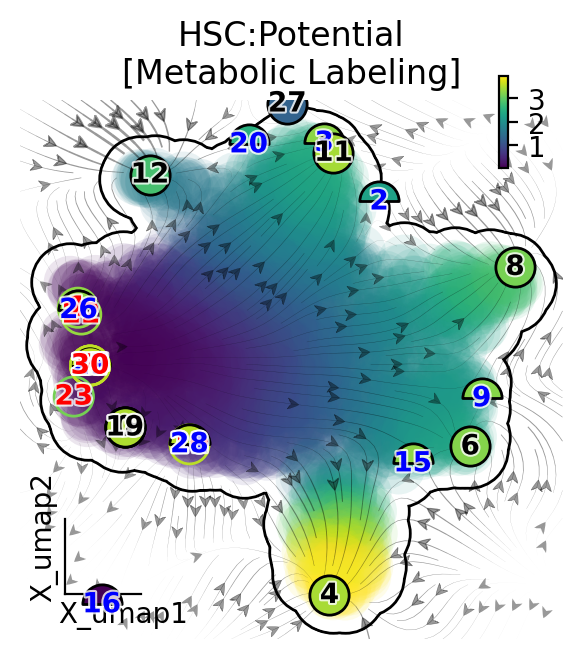

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata, 
                  basis='umap', fps_basis='umap',
                  background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('HSC:Potential\n[Metabolic Labeling]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()


ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Label_HSC_Potential.png', dpi=300, bbox_inches='tight')
fig.savefig(f'figures/fig3/Label_HSC_Potential.svg', dpi=300, bbox_inches='tight')

In [88]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap']['confidence']

fixed_points = [1,12,8,4,6,11]

adata_load_fix_points.uns['VecFld_umap']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['confidence']=conf[fixed_points]

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
#ov.plot_set()
dyn.pl.topography(adata_load_fix_points, basis='umap',
                  fps_basis='umap',background='white', 
                  color=[ 'cell_type'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('HSC:Topography\n[Metabolic Labeling]',fontsize=12)

ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig3/Label_HSC_Topography.png', dpi=300, bbox_inches='tight')
fig.savefig(f'figures/fig3/Label_HSC_Topography.svg', dpi=300, bbox_inches='tight')

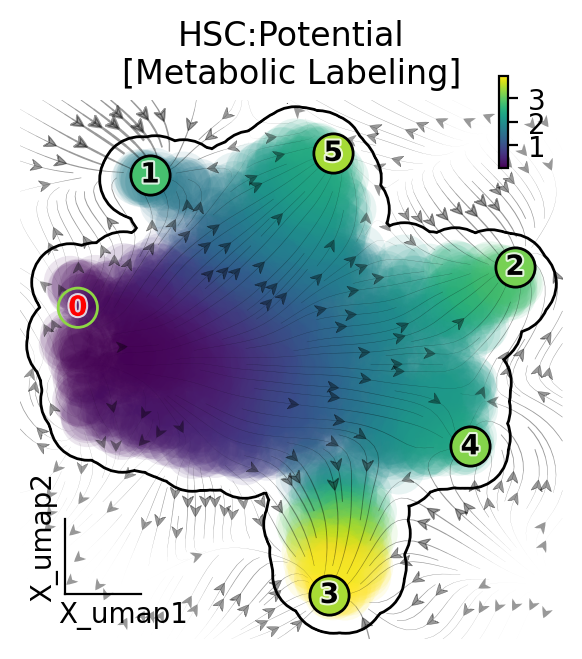

In [97]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata_load_fix_points, 
                  basis='umap', fps_basis='umap',
                  background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('HSC:Potential\n[Metabolic Labeling]',fontsize=12)

ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Label_HSC_Potential.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figures/fig3/Label_HSC_Potential.svg', dpi=300, bbox_inches='tight')

In [98]:
dyn.tl.cell_velocities(
    adata, basis='pca',
    X=adata.layers["M_t"],
    V=adata.layers["velocity_alpha_minus_gamma_s"]
)
dyn.vf.VectorField(adata, basis='pca')

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [SparseVFC] completed [0.0349s]
|-----> [VectorField] completed [0.0696s]


In [99]:
basis = "pca"
dyn.vf.speed(adata, basis=basis)
dyn.vf.divergence(adata, basis=basis)
dyn.vf.acceleration(adata, basis=basis)
dyn.vf.curvature(adata, basis=basis)


Calculating divergence: 100%|██████████| 2/2 [00:00<00:00, 32.99it/s]


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


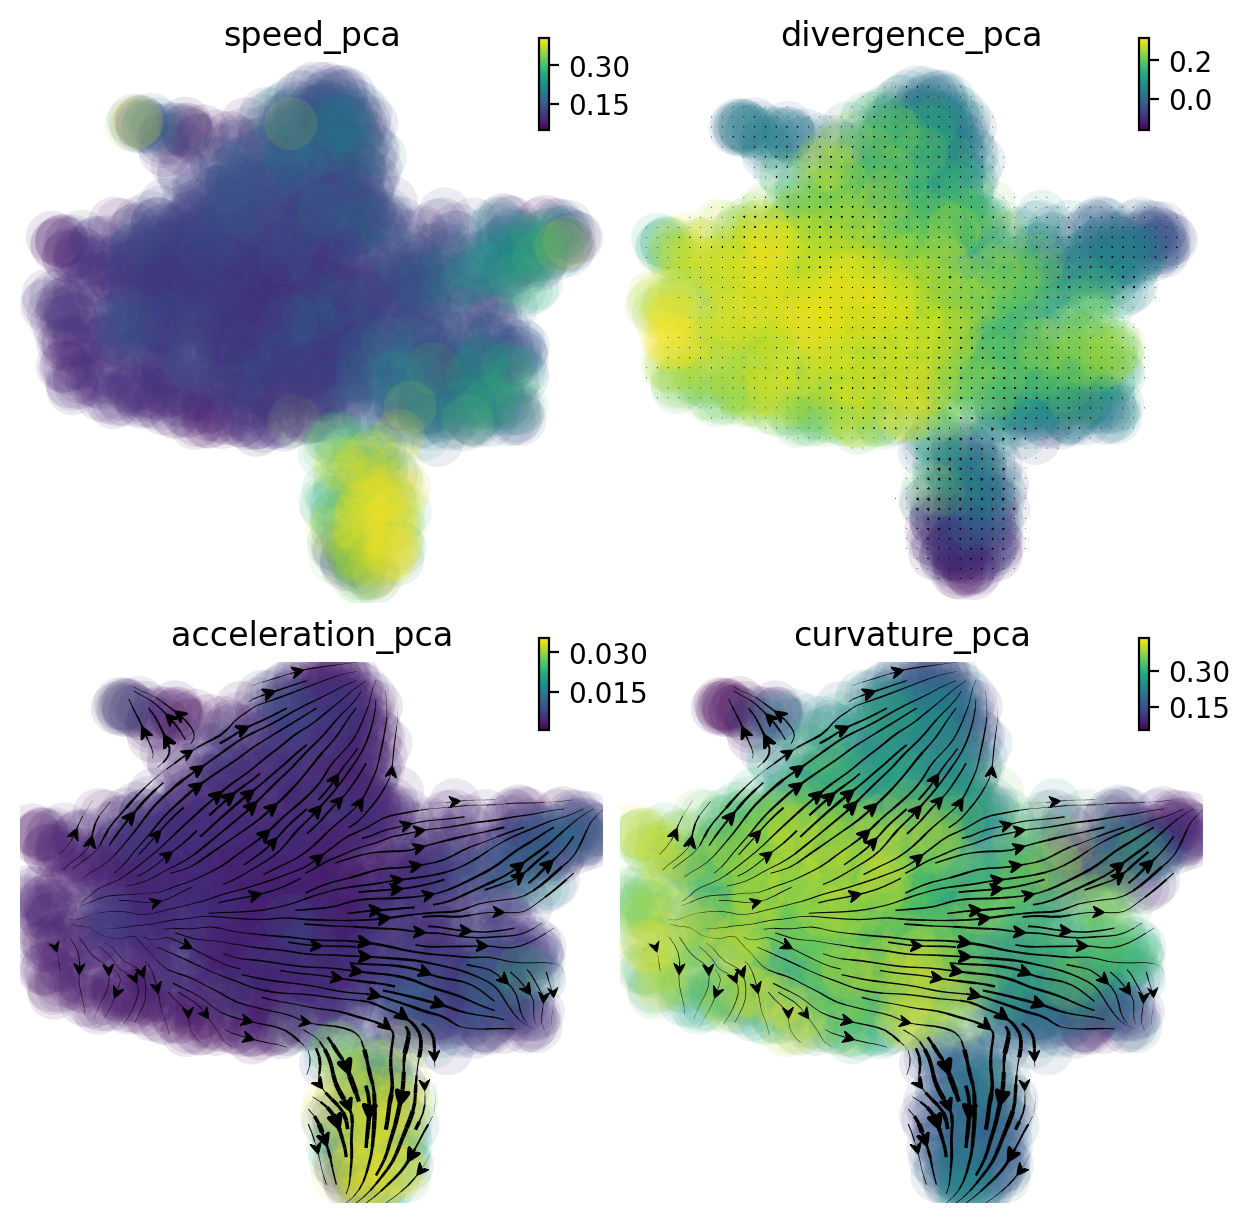

In [102]:
fig, axes = plt.subplots(ncols=2, nrows=2,
 constrained_layout=True, figsize=(6, 6))
dyn.pl.umap(
adata, color="speed_" + basis,
ax=axes[0, 0], save_show_or_return="return")
dyn.pl.grid_vectors(
    adata,
    color="divergence_" + basis,
    ax=axes[0, 1],
    quiver_length=12,
    quiver_size=12,
    save_show_or_return="return",
)
dyn.pl.streamline_plot(
adata, color="acceleration_" + basis,
ax=axes[1, 0], save_show_or_return="return")
dyn.pl.streamline_plot(
adata, color="curvature_" + basis,
ax=axes[1, 1], save_show_or_return="return")
plt.show()


In [103]:
progenitor =adata.obs_names[adata.obs.cell_type.isin(['HSC'])]
dyn.pd.fate(
    adata, basis='umap', 
    init_cells=progenitor, 
    interpolation_num=100,
    direction='forward',
    inverse_transform=False, average=False
)


uniformly sampling points along a trajectory: 100%|██████████| 309/309 [00:00<00:00, 1183.14it/s]


AnnData object with n_obs × n_vars = 1947 × 21805
    obs: 'batch', 'cell_type', 'time', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'new_Size_Factor', 'initial_new_cell_size', 'ntr', 'control_point_umap', 'inlier_prob_umap', 'obs_vf_angle_umap', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'speed_pca', 'divergence_pca', 'acceleration_pca', 'curvature_pca'
    var: 'gene_name_mapping', 'query', 'scopes', '_id', '_score', 'symbol', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_m', 'log_cv', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'genes_to_use', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'neighbors', 'time_3_vel_params_names'

<Axes: title={'center': 'cell_type'}, xlabel='umap_1', ylabel='umap_2'>

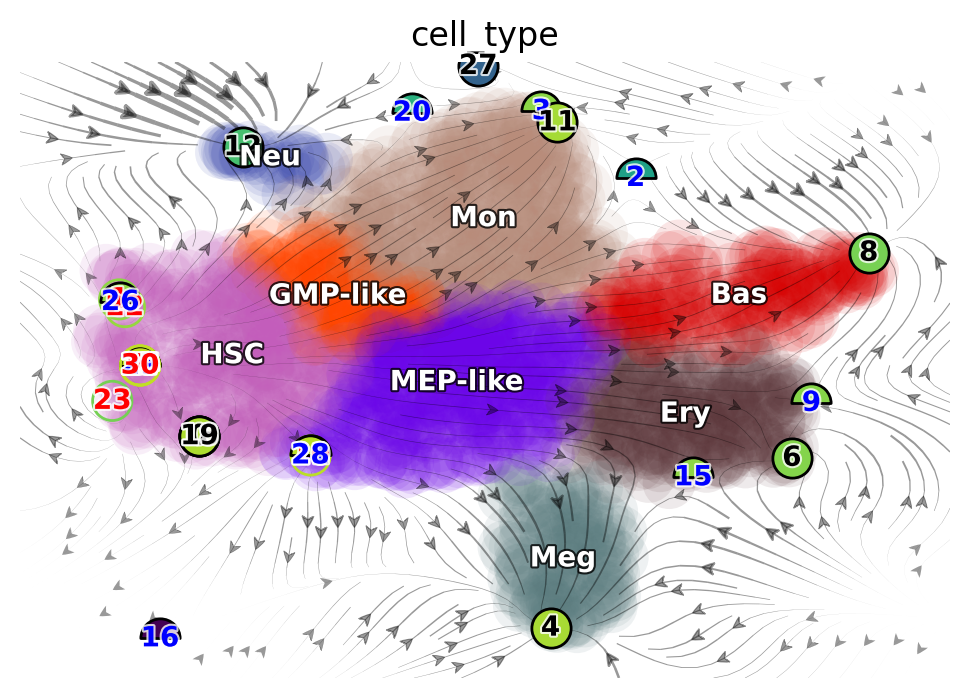

In [104]:
%matplotlib inline
dyn.pl.topography(
    adata, color='cell_type', 
    save_show_or_return='return'
)


In [105]:
dyn.mv.animate_fates(
    adata, color='cell_type', 
    basis='umap', n_steps=100, 
    fig=fig, ax=ax,save_show_or_return='save', 
    logspace=True, max_time=None
)


MovieWriter imagemagick unavailable; using Pillow instead.
